In [ ]:
#Features 2,5,6,8

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from numpy import mean
from numpy import std
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from joblib.numpy_pickle_utils import xrange
from numpy import *

In [ ]:
dfL1 = pd.read_excel("Phuket_landslide_normalized_finaldata1.xlsx")

In [ ]:
X=dfL1.drop("yi", axis=1).astype(float)
y=dfL1['yi'].astype(float)

In [ ]:
y1 = []  # Initialize y as a list
for i in range(len(dfL1['yi'])):  # Iterate using range()
  if dfL1['yi'][i]==1:
    y1.append(1)
  else:
    y1.append(0)

y1 = pd.DataFrame(y1, columns=['yi'])

In [ ]:
X = X.drop(['Unnamed: 0'], axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y1, test_size=0.3, random_state=4)
X1_train=X_train.drop(columns =['x','y','mosaic_phuket_Clip','Aspect_mosai1','Curvatu_mosa1','Distance_to_Fault','Distance_to_Rivers','Kriging_rain1','TWI_phuket','DMR_Geology'])
X1_test=X_test.drop(columns =['x','y','mosaic_phuket_Clip','Aspect_mosai1','Curvatu_mosa1','Distance_to_Fault','Distance_to_Rivers','Kriging_rain1','TWI_phuket','DMR_Geology'])
X11=X.drop(columns =['x','y','mosaic_phuket_Clip','Aspect_mosai1','Curvatu_mosa1','Distance_to_Fault','Distance_to_Rivers','Kriging_rain1','TWI_phuket','DMR_Geology'])

In [ ]:
Dfxtrain=pd.DataFrame(X_train.loc[:,["x","y"]])
Dfxtrain.to_excel("X_train_new.xlsx")
Dfxtest=pd.DataFrame(X_test.loc[:,["x","y"]])
Dfxtest.to_excel("X_test_new.xlsx")

In [ ]:
X1_train.columns = X1_train.columns.astype(str)
X1_test.columns = X1_test.columns.astype(str)
X11.columns = X11.columns.astype(str)

In [ ]:
log_model=LogisticRegression()
log_model.fit(X1_train.values, y_train.values)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
from numpy import mean
from numpy import std
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
k_folds = KFold(n_splits = 10, random_state=4, shuffle=True)
scores = cross_val_score(log_model, X11, y, cv = k_folds)
print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("SD CV Score: ", scores.std())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [0.89285714 0.96428571 0.85714286 0.92857143 0.92857143 0.85714286
 0.89285714 0.82142857 0.89285714 0.78571429]
Average CV Score:  0.8821428571428571
SD CV Score:  0.05063373885270654
Number of CV Scores used in Average:  10


In [ ]:
PredictionsTe=log_model.predict(X1_test.values)
from sklearn.metrics import classification_report
print(classification_report(y_test,PredictionsTe))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93        56
           1       0.83      0.89      0.86        28

    accuracy                           0.90        84
   macro avg       0.89      0.90      0.89        84
weighted avg       0.91      0.90      0.91        84



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,PredictionsTe)

array([[51,  5],
       [ 3, 25]])

In [ ]:
PredictionsTr=log_model.predict(X1_train.values)
from sklearn.metrics import classification_report
print(classification_report(y_train,PredictionsTr))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89       109
           1       0.86      0.87      0.87        87

    accuracy                           0.88       196
   macro avg       0.88      0.88      0.88       196
weighted avg       0.88      0.88      0.88       196



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train,PredictionsTr)

array([[97, 12],
       [11, 76]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,PredictionsTe)

0.9047619047619048

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train,PredictionsTr)

0.8826530612244898

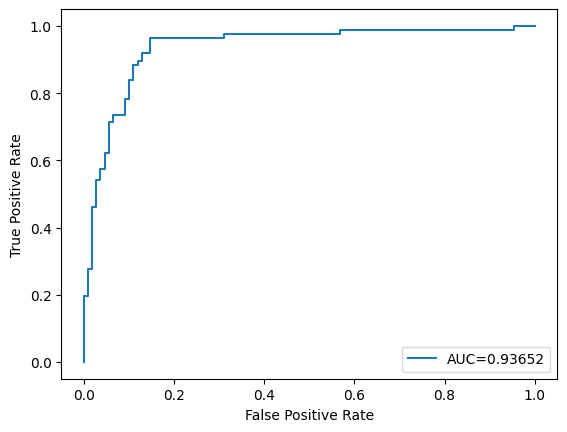

In [ ]:
#train ROC
from sklearn import metrics
y_pred_probaTr = log_model.predict_proba(X1_train.values)[::,1]
fprTr, tprTr, _ = metrics.roc_curve(y_train.values,  y_pred_probaTr)
aucTr = metrics.roc_auc_score(y_train, y_pred_probaTr)
plt.plot(fprTr,tprTr,label="AUC="+str("%.5f" %aucTr))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

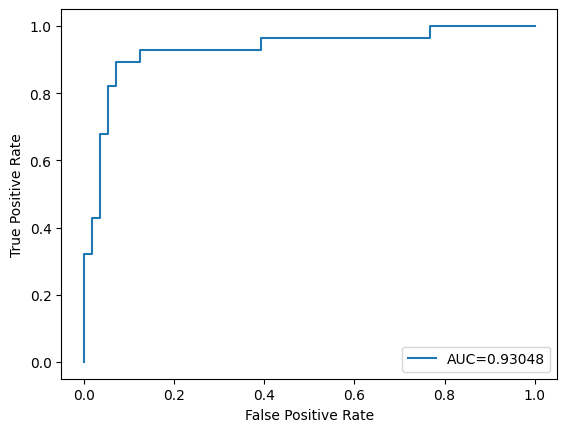

In [ ]:
from sklearn import metrics
y_pred_proba = log_model.predict_proba(X1_test.values)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test.values,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="AUC="+str("%.5f" %auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

In [ ]:
proba = log_model.predict_proba(X11.values)[:,1]
d=pd.DataFrame(proba)
DR1=pd.DataFrame(X.loc[:,["x","y"]])
DR=pd.concat([DR1,d],axis=1)
DR.to_excel("XYandProba_logistic4factors_phuket.xlsx")

In [ ]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV
parameters = {'C': [1,2,3,4,5,6,7],
              'kernel': ['linear']
              }
cl = svm.SVC()
grid = GridSearchCV(cl, parameters, cv=5)
grid.fit(X1_train, y_train)
print(grid.best_params_)
print(grid.best_estimator_)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

{'C': 6, 'kernel': 'linear'}
SVC(C=6, kernel='linear')


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [ ]:
from sklearn import svm
clf = svm.SVC(kernel='linear', C=6)
k_folds = KFold(n_splits = 10, random_state=4, shuffle=True)
scores = cross_val_score(clf, X11, y, cv = k_folds)
print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("SD CV Score: ", scores.std())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [0.85714286 0.96428571 0.82142857 0.96428571 0.89285714 0.89285714
 0.89285714 0.82142857 0.92857143 0.85714286]
Average CV Score:  0.8892857142857142
SD CV Score:  0.04909902530309831
Number of CV Scores used in Average:  10


In [ ]:
clfSVMli = svm.SVC(kernel='linear', C=6)

#Train the model using the training sets
clfSVMli.fit(X1_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=6, kernel='linear')

In [ ]:
#Predict the response for test dataset
y_predTe = clfSVMli.predict(X1_test)
print(confusion_matrix(y_test,y_predTe))
print(classification_report(y_test, y_predTe))
accuracy_score(y_test, y_predTe)

[[50  6]
 [ 4 24]]
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        56
           1       0.80      0.86      0.83        28

    accuracy                           0.88        84
   macro avg       0.86      0.88      0.87        84
weighted avg       0.88      0.88      0.88        84



0.8809523809523809

In [ ]:
#Train
#Predict the response for train dataset
y_predTr = clfSVMli.predict(X1_train)
print(confusion_matrix(y_train,y_predTr))
print(classification_report(y_train, y_predTr))
accuracy_score(y_train, y_predTr)

[[96 13]
 [ 8 79]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       109
           1       0.86      0.91      0.88        87

    accuracy                           0.89       196
   macro avg       0.89      0.89      0.89       196
weighted avg       0.89      0.89      0.89       196



0.8928571428571429

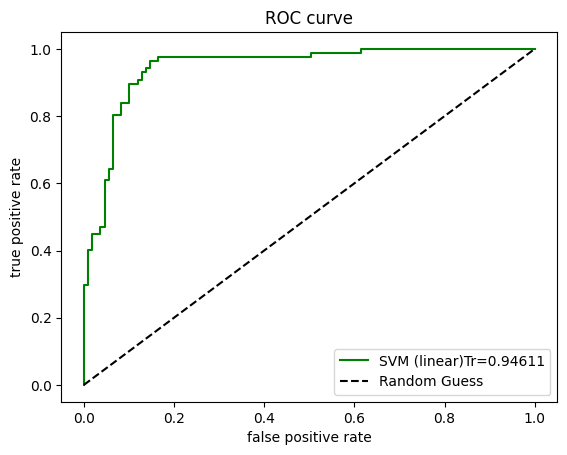

In [ ]:
#ROC train
decision_scoresTr = clfSVMli.decision_function(X1_train)
#decision_scores1 = clfSVMli.decision_function(X11)
fpr2Tr, tpr2Tr, thres1 = roc_curve(y_train, decision_scoresTr)
aucsvmlTr = metrics.roc_auc_score(y_train, decision_scoresTr)
#print('AUC: {:.8f}'.format(roc_auc_score(ys_test, decision_scores)))

# roc curve
plt.plot(fpr2Tr, tpr2Tr, "g", label='SVM (linear)Tr='+str("%.5f" %aucsvmlTr))
plt.plot([0,1],[0,1], "k--", label='Random Guess')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve")
plt.show()

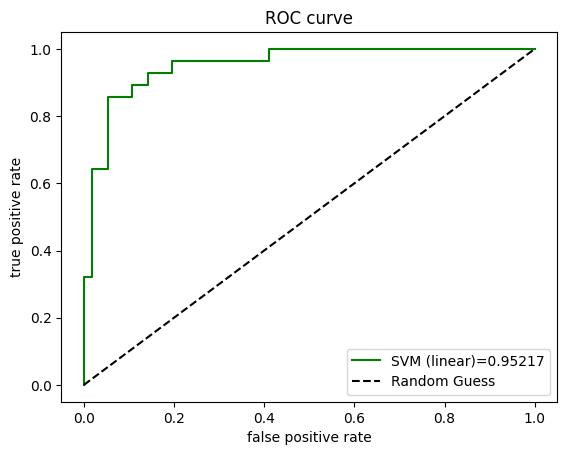

In [ ]:
#ROC Test
decision_scores = clfSVMli.decision_function(X1_test)
#decision_scores1 = clfSVMli.decision_function(X11)
fpr2, tpr2, thres = roc_curve(y_test, decision_scores)
aucsvml = metrics.roc_auc_score(y_test, decision_scores)
#print('AUC: {:.8f}'.format(roc_auc_score(ys_test, decision_scores)))

# roc curve
plt.plot(fpr2, tpr2, "g", label='SVM (linear)='+str("%.5f" %aucsvml))
plt.plot([0,1],[0,1], "k--", label='Random Guess')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve")
plt.show()

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
# Create a calibrated classifier using Platt Scaling
calibrated_clfL = CalibratedClassifierCV(clfSVMli, method='sigmoid')
calibrated_clfL.fit(X1_train, y_train)

# Make predictions on the data set
ys_probaL = calibrated_clfL.predict_proba(X11)[:,1]
DS1=pd.DataFrame(X.loc[:,["x","y"]])
dsvml=pd.DataFrame(ys_probaL)
DS=pd.concat([DS1,dsvml],axis=1)
DS.to_excel("XYandProba_SVM4factors_Linear_Phuket.xlsx")

In [ ]:
from sklearn.model_selection import GridSearchCV
parameters = {'C': [0.5,1,2,5,10,15,20,25],
              'gamma':[0.5,1,1.5,2,2.5],
              'kernel': ['rbf']
              }
cl = svm.SVC()
grid = GridSearchCV(cl, parameters, cv=5)
grid.fit(X1_train, y_train)
print(grid.best_params_)
print(grid.best_estimator_)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

{'C': 1, 'gamma': 1.5, 'kernel': 'rbf'}
SVC(C=1, gamma=1.5)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [ ]:
from sklearn import svm
clfSVMRBF = svm.SVC(kernel="rbf",C=1,gamma=1.5)
clfSVMRBF.fit(X1_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=1, gamma=1.5)

In [ ]:
k_folds = KFold(n_splits = 10, random_state=4, shuffle=True)
scores = cross_val_score(clfSVMRBF, X11, y, cv = k_folds)
print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("SD CV Score: ", scores.std())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [0.85714286 0.96428571 0.85714286 0.92857143 0.89285714 0.89285714
 0.89285714 0.82142857 0.92857143 0.85714286]
Average CV Score:  0.8892857142857142
SD CV Score:  0.040563631041430556
Number of CV Scores used in Average:  10


In [ ]:
#Predict the response for test dataset
ys_pred = clfSVMRBF.predict(X1_test)
print(confusion_matrix(y_test,ys_pred))
print(classification_report(y_test, ys_pred))
accuracy_score(y_test, ys_pred)

[[49  7]
 [ 3 25]]
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        56
           1       0.78      0.89      0.83        28

    accuracy                           0.88        84
   macro avg       0.86      0.88      0.87        84
weighted avg       0.89      0.88      0.88        84



0.8809523809523809

In [ ]:
#Predict the response for train dataset
ys_predTr = clfSVMRBF.predict(X1_train)
print(confusion_matrix(y_train,ys_predTr))
print(classification_report(y_train, ys_predTr))
accuracy_score(y_train, ys_predTr)

[[95 14]
 [ 6 81]]
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       109
           1       0.85      0.93      0.89        87

    accuracy                           0.90       196
   macro avg       0.90      0.90      0.90       196
weighted avg       0.90      0.90      0.90       196



0.8979591836734694

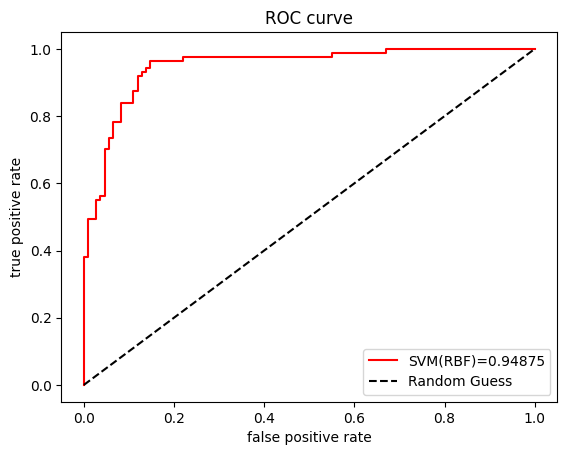

In [ ]:
#ROCtrain
decision_scores = clfSVMRBF.decision_function(X1_train)
#decision_scores1 = clfSVMRBF.decision_function(X11)
fpr1Tr, tpr1Tr, thres = roc_curve(y_train, decision_scores)
aucsvmRTr = metrics.roc_auc_score(y_train, decision_scores)
#print('AUC: {:.8f}'.format(roc_auc_score(ys_test, decision_scores)))

# roc curve
plt.plot(fpr1Tr, tpr1Tr, "r", label='SVM(RBF)='+str("%.5f" %aucsvmRTr))
plt.plot([0,1],[0,1], "k--", label='Random Guess')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve")
plt.show()

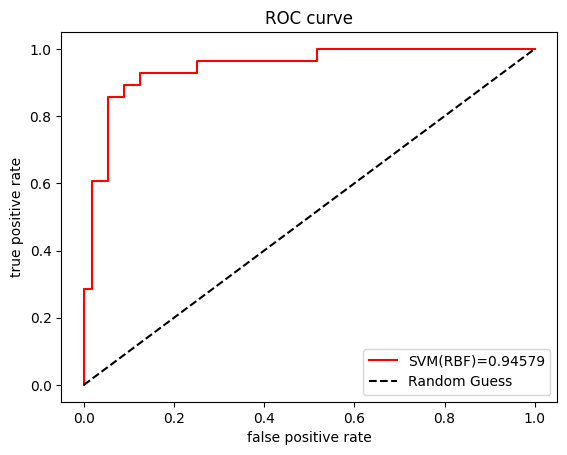

In [ ]:
#ROCtest
decision_scores = clfSVMRBF.decision_function(X1_test)
#decision_scores1 = clfSVMRBF.decision_function(X11)
fpr1, tpr1, thres = roc_curve(y_test, decision_scores)
aucsvmR = metrics.roc_auc_score(y_test, decision_scores)
#print('AUC: {:.8f}'.format(roc_auc_score(ys_test, decision_scores)))

# roc curve
plt.plot(fpr1, tpr1, "r", label='SVM(RBF)='+str("%.5f" %aucsvmR))
plt.plot([0,1],[0,1], "k--", label='Random Guess')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve")
plt.show()

In [ ]:
# Create a calibrated classifier using Platt Scaling
calibrated_clfR = CalibratedClassifierCV(clfSVMRBF, method='sigmoid')
calibrated_clfR.fit(X1_train, y_train)

# Make predictions on the data set
ys_probaR = calibrated_clfR.predict_proba(X11)[:,1]
DS1=pd.DataFrame(X.loc[:,["x","y"]])
dsvmR=pd.DataFrame(ys_probaR)
DSR=pd.concat([DS1,dsvmR],axis=1)
DSR.to_excel("XYandProba_SVM4factors_RBF_Phuket.xlsx")

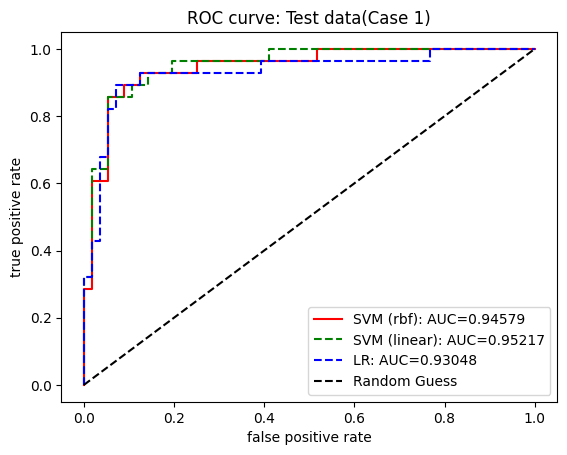

In [ ]:
# roc curve test
plt.plot(fpr1, tpr1, "r-", label='SVM (rbf): AUC='+str("%.5f" %aucsvmR))
plt.plot(fpr2, tpr2, "g--", label='SVM (linear): AUC='+str("%.5f" %aucsvml))
plt.plot(fpr,tpr, "b--",label='LR: AUC='+str("%.5f" %auc))
plt.plot([0,1],[0,1], "k--", label='Random Guess')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve: Test data(Case 1)")
plt.show()

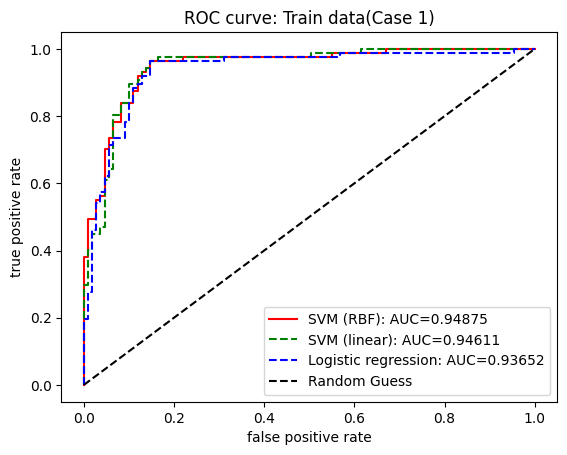

In [ ]:
# roc curve train
plt.plot(fpr1Tr, tpr1Tr, "r-", label='SVM (RBF): AUC='+str("%.5f" %aucsvmRTr))
plt.plot(fpr2Tr, tpr2Tr, "g--", label='SVM (linear): AUC='+str("%.5f" %aucsvmlTr))
plt.plot(fprTr,tprTr, "b--",label='Logistic regression: AUC='+str("%.5f" %aucTr))
plt.plot([0,1],[0,1], "k--", label='Random Guess')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve: Train data(Case 1)")
plt.show()

In [ ]:
class NeuralNet(object):
    def __init__(self, num_features): # Add num_features as an argument
        # Generate random numbers
        random.seed(1)

        # Assign random weights to a matrix with num_features rows
        self.synaptic_weights = 2 * random.random((num_features, 1)) - 1

    # The Sigmoid function
    def __sigmoid(self, x):
        return 1 / (1 + exp(-x))

    # The derivative of the Sigmoid function.
    # This is the gradient of the Sigmoid curve.
    def __sigmoid_derivative(self, x):
        return x * (1 - x)

    # Train the neural network and adjust the weights each time.
    def train(self, inputs, outputs, training_iterations):
        for iteration in xrange(training_iterations):
            # Pass the training set through the network.
            output = self.learn(inputs)

            # Calculate the error
            error = outputs - output

            # Reshape error to be a column vector
            error = error.reshape(-1, 1)

            # No need to transpose inputs, instead transpose synaptic_weights in the dot product
            factor = np.dot(inputs.T, error * self.__sigmoid_derivative(output))

            self.synaptic_weights += factor

    def learn(self, inputs):
        # Transpose synaptic_weights for correct matrix multiplication
        # Changed from inputs.T to self.synaptic_weights.T for correct matrix multiplication
        return self.__sigmoid(np.dot(inputs, self.synaptic_weights))

    def predict(self, inputs):
        """Predicts the output for given inputs using the learned weights."""
        return self.learn(inputs)  # Use the 'learn' method for prediction


if __name__ == "__main__":
    num_features = X1_train.shape[1]
    # Initialize
    neural_network = NeuralNet(num_features)

    # The training set.
    # Remove the transpose operation here to keep inputs in the correct shape
    inputs = X1_train
    outputs = np.array(y_train).reshape(-1, 1)  # Reshape outputs to be a column vector using reshape

    # Train the neural network
    neural_network.train(inputs, outputs, 1000)

In [ ]:
y_train = np.array(y_train)

In [ ]:
PredictTrain = []
for i in range(len(X1_train)):
  if neural_network.learn(X1_train)[i]>=0.5:
    PredictTrain.append(1)
  else:
    PredictTrain.append(0)
print(confusion_matrix(y_train,PredictTrain))
print(classification_report(y_train, PredictTrain))
accuracy_score(y_train, PredictTrain)

[[97 12]
 [ 8 79]]
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       109
           1       0.87      0.91      0.89        87

    accuracy                           0.90       196
   macro avg       0.90      0.90      0.90       196
weighted avg       0.90      0.90      0.90       196



0.8979591836734694

In [ ]:
PredictTest = []
for i in range(len(X1_test)):
  if neural_network.learn(X1_test)[i]>=0.7:
    PredictTest.append(1)
  else:
    PredictTest.append(0)
print(confusion_matrix(y_test,PredictTest))
print(classification_report(y_test, PredictTest))
accuracy_score(y_test, PredictTest)

[[54  2]
 [ 7 21]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        56
           1       0.91      0.75      0.82        28

    accuracy                           0.89        84
   macro avg       0.90      0.86      0.87        84
weighted avg       0.89      0.89      0.89        84



0.8928571428571429

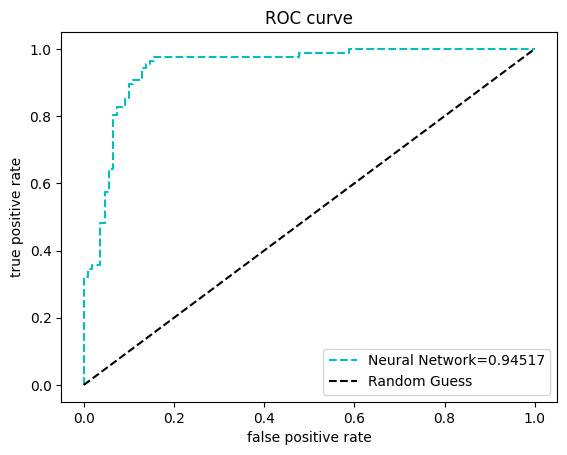

In [ ]:
#ROC train
#decision_scoresTr = clfSVMli.decision_function(X1_train)
fprNN1Tr, tprNN1Tr, thres1 = roc_curve(y_train, neural_network.learn(X1_train))
aucNN1Tr = metrics.roc_auc_score(y_train, neural_network.learn(X1_train))

# roc curve
plt.plot(fprNN1Tr, tprNN1Tr, "c--", label='Neural Network='+str("%.5f" %aucNN1Tr))
plt.plot([0,1],[0,1], "k--", label='Random Guess')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve")
plt.show()

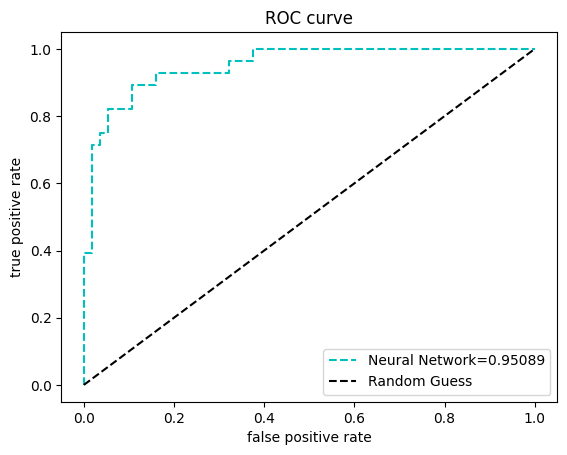

In [ ]:
#ROC Test
fprNN1te, tprNN1te, thres = roc_curve(y_test, neural_network.learn(X1_test))
aucNN1te = metrics.roc_auc_score(y_test, neural_network.learn(X1_test))


# roc curve
plt.plot(fprNN1te, tprNN1te, "c--", label='Neural Network='+str("%.5f" %aucNN1te))
plt.plot([0,1],[0,1], "k--", label='Random Guess')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve")
plt.show()

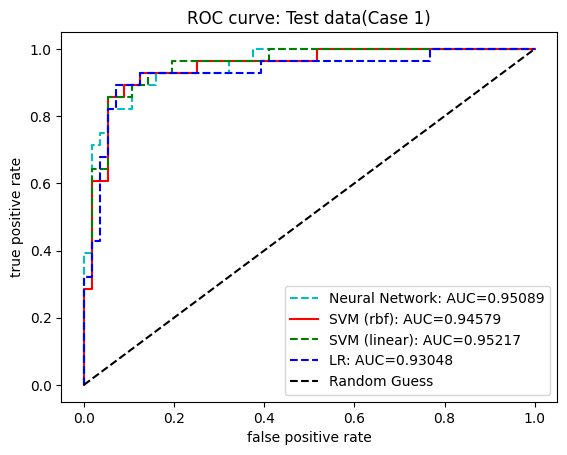

In [ ]:
# roc curve test
plt.plot(fprNN1te, tprNN1te, "c--", label='Neural Network: AUC='+str("%.5f" %aucNN1te))
plt.plot(fpr1, tpr1, "r-", label='SVM (rbf): AUC='+str("%.5f" %aucsvmR))
plt.plot(fpr2, tpr2, "g--", label='SVM (linear): AUC='+str("%.5f" %aucsvml))
plt.plot(fpr,tpr, "b--",label='LR: AUC='+str("%.5f" %auc))
plt.plot([0,1],[0,1], "k--", label='Random Guess')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve: Test data(Case 1)")
plt.plot()
plt.savefig('ROCtestCase1.svg', format='svg')

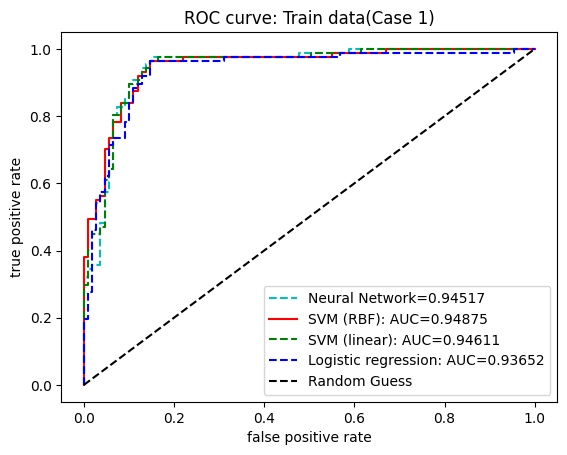

In [ ]:
# roc curve train
plt.plot(fprNN1Tr, tprNN1Tr, "c--", label='Neural Network='+str("%.5f" %aucNN1Tr))
plt.plot(fpr1Tr, tpr1Tr, "r-", label='SVM (RBF): AUC='+str("%.5f" %aucsvmRTr))
plt.plot(fpr2Tr, tpr2Tr, "g--", label='SVM (linear): AUC='+str("%.5f" %aucsvmlTr))
plt.plot(fprTr,tprTr, "b--",label='Logistic regression: AUC='+str("%.5f" %aucTr))
plt.plot([0,1],[0,1], "k--", label='Random Guess')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve: Train data(Case 1)")
plt.plot()
plt.savefig('ROCtrainCase1.svg', format='svg')